# Zadanie domowe -- interpolacja dwusześcienna

Interpolacja dwusześcienna, to podobnie jak w przypadku interpolacji dwuliniowej, rozszerzenie idei interpolacji jednowymiarowej na dwuwymiarową siatkę.
W trakcie jej obliczania wykorzystywane jest 16 pikseli z otoczenia (dla dwuliniowej 4).
Skutkuje to zwykle lepszymi wynikami - obraz wyjściowy jest bardziej gładki i z mniejszą liczbą artefaktów.
Ceną jest znaczny wzrost złożoności obliczeniowej (zostało to zaobserwowane podczas ćwiczenia).

Interpolacja dana jest wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\end{equation}

Zadanie sprowadza się zatem do wyznaczenia 16 współczynników $a_{ij}$.
W tym celu wykorzystuje się, oprócz wartość w puntach $A$ (0,0), $B$ (1 0), $C$ (1,1), $D$ (0,1) (por. rysunek dotyczący interpolacji dwuliniowej), także pochodne cząstkowe $A_x$, $A_y$, $A_{xy}$.
Pozwala to rozwiązać układ 16-tu równań.

Jeśli zgrupujemy parametry $a_{ij}$:
\begin{equation}
a = [ a_{00}~a_{10}~a_{20}~a_{30}~a_{01}~a_{11}~a_{21}~a_{31}~a_{02}~a_{12}~a_{22}~a_{32}~a_{03}~a_{13}~a_{23}~a_{33}]
\end{equation}

i przyjmiemy:
\begin{equation}
x = [A~B~D~C~A_x~B_x~D_x~C_x~A_y~B_y~D_y~C_y~A_{xy}~B_{xy}~D_{xy}~C_{xy}]^T
\end{equation}

To zagadnienie można opisać w postaci równania liniowego:
\begin{equation}
Aa = x
\end{equation}
gdzie macierz $A^{-1}$ dana jest wzorem:

\begin{equation}
A^{-1} =
\begin{bmatrix}
1& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0 \\
0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
-3&  3&  0&  0& -2& -1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
2& -2&  0&  0&  1&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0& -3&  3&  0&  0& -2& -1&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  2& -2&  0&  0&  1&  1&  0&  0 \\
-3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0& -3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0 \\
9& -9& -9&  9&  6&  3& -6& -3&  6& -6&  3& -3&  4&  2&  2&  1 \\
-6&  6&  6& -6& -3& -3&  3&  3& -4&  4& -2&  2& -2& -2& -1& -1 \\
2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0 \\
-6&  6&  6& -6& -4& -2&  4&  2& -3&  3& -3&  3& -2& -1& -2& -1 \\
4& -4& -4&  4&  2&  2& -2& -2&  2& -2&  2& -2&  1&  1&  1&  1 \\
\end{bmatrix}
\end{equation}

Potrzebne w rozważaniach pochodne cząstkowe obliczane są wg. następującego przybliżenia (przykład dla punktu A):
\begin{equation}
A_x = \frac{I(i+1,j) - I(i-1,j)}{2}
\end{equation}
\begin{equation}
A_y = \frac{I(i,j+1) - I(i,j-1)}{2}
\end{equation}
\begin{equation}
A_{xy} = \frac{I(i+1,j+1) - I(i-1,j) - I(i,j-1) + I(i,j)}{4}
\end{equation}

## Zadanie

Wykorzystując podane informacje zaimplementuj interpolację dwusześcienną.
Uwagi:
- macierz $A^{-1}$ dostępna jest w pliku *a_invert.py*
- trzeba się zastanowić nad potencjalnym wykraczaniem poza zakres obrazka (jak zwykle).

Ponadto dokonaj porównania liczby operacji arytmetycznych i dostępów do pamięci koniecznych przy realizacji obu metod interpolacji: dwuliniowej i dwusześciennej.

In [1]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/'

fileName = "ainvert.py"
if not os.path.exists(fileName):
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

#TODO Do samodzielnej implementacji

import ainvert
import numpy as np
import cv2
from ainvert import A_invert

def bicubic_interpolation_manual(img, scale):
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale), int(w * scale)
    out = np.zeros((new_h, new_w), dtype=np.uint8)

    for y_new in range(new_h):
        for x_new in range(new_w):
            x = x_new / scale
            y = y_new / scale

            i = int(np.floor(x))
            j = int(np.floor(y))

            u = x - i
            v = y - j

            if i < 1 or j < 1 or i+2 >= w or j+2 >= h:
                out[y_new, x_new] = img[min(j, h-1), min(i, w-1)]
                continue

            region = img[j-1:j+3, i-1:i+3]

            A = region[1,1]
            B = region[1,2]
            D = region[2,1]
            C = region[2,2]

            def dx(p, q): return (img[q, p+1] - img[q, p-1]) / 2
            def dy(p, q): return (img[q+1, p] - img[q-1, p]) / 2
            def dxy(p, q): return (img[q+1, p+1] - img[q-1, p+1] - img[q+1, p-1] + img[q-1, p-1]) / 4

            A_x = dx(i, j)
            B_x = dx(i+1, j)
            D_x = dx(i, j+1)
            C_x = dx(i+1, j+1)

            A_y = dy(i, j)
            B_y = dy(i+1, j)
            D_y = dy(i, j+1)
            C_y = dy(i+1, j+1)

            A_xy = dxy(i, j)
            B_xy = dxy(i+1, j)
            D_xy = dxy(i, j+1)
            C_xy = dxy(i+1, j+1)

            x_vec = np.array([A, B, D, C, A_x, B_x, D_x, C_x,
                              A_y, B_y, D_y, C_y, A_xy, B_xy, D_xy, C_xy])

            a = A_invert @ x_vec
            a = a.reshape(4, 4)

            Iuv = sum(a[m, n] * (u ** m) * (v ** n) for m in range(4) for n in range(4))
            out[y_new, x_new] = np.clip(Iuv, 0, 255)

    return out


C:\Users\User\AppData\Local\Temp\ipykernel_19864\757420421.py:48: RuntimeWarning: overflow encountered in scalar subtract
  def dx(p, q): return (img[q, p+1] - img[q, p-1]) / 2
C:\Users\User\AppData\Local\Temp\ipykernel_19864\757420421.py:49: RuntimeWarning: overflow encountered in scalar subtract
  def dy(p, q): return (img[q+1, p] - img[q-1, p]) / 2
C:\Users\User\AppData\Local\Temp\ipykernel_19864\757420421.py:50: RuntimeWarning: overflow encountered in scalar subtract
  def dxy(p, q): return (img[q+1, p+1] - img[q-1, p+1] - img[q+1, p-1] + img[q-1, p-1]) / 4
C:\Users\User\AppData\Local\Temp\ipykernel_19864\757420421.py:50: RuntimeWarning: overflow encountered in scalar add
  def dxy(p, q): return (img[q+1, p+1] - img[q-1, p+1] - img[q+1, p-1] + img[q-1, p-1]) / 4


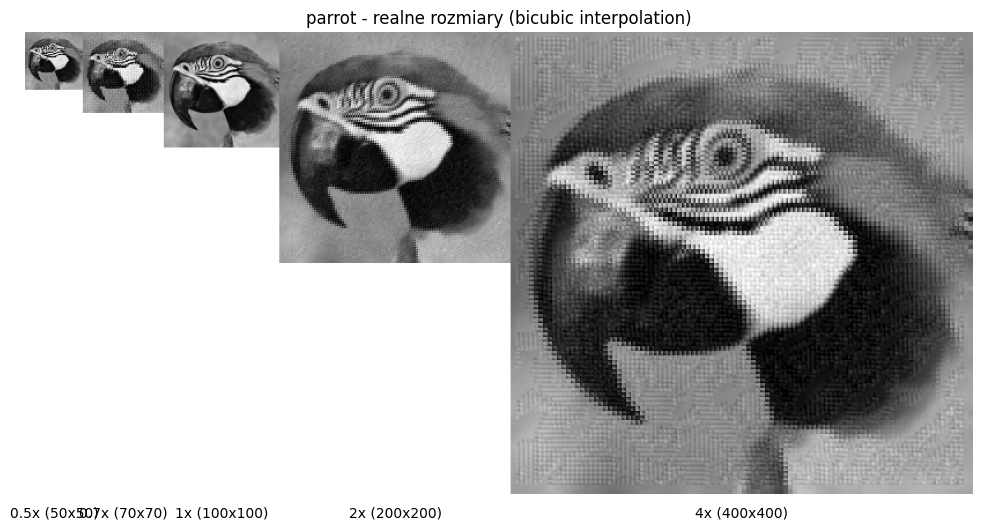

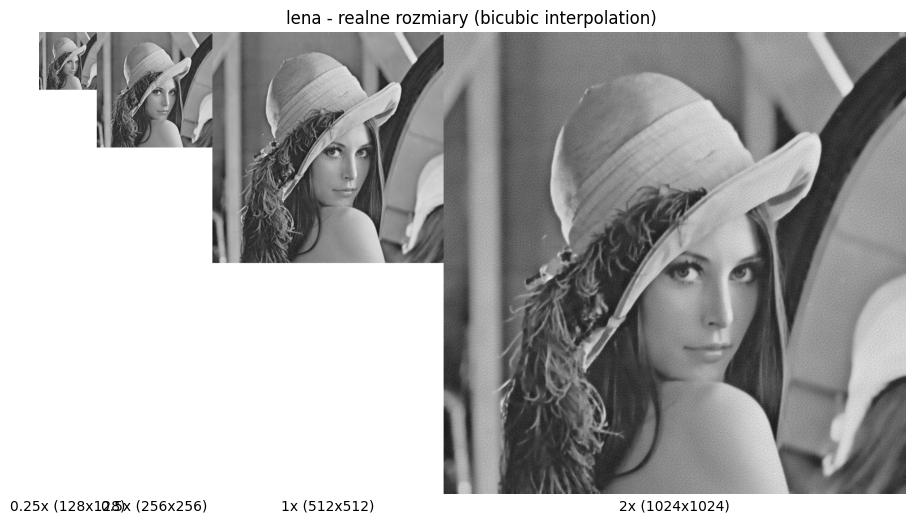

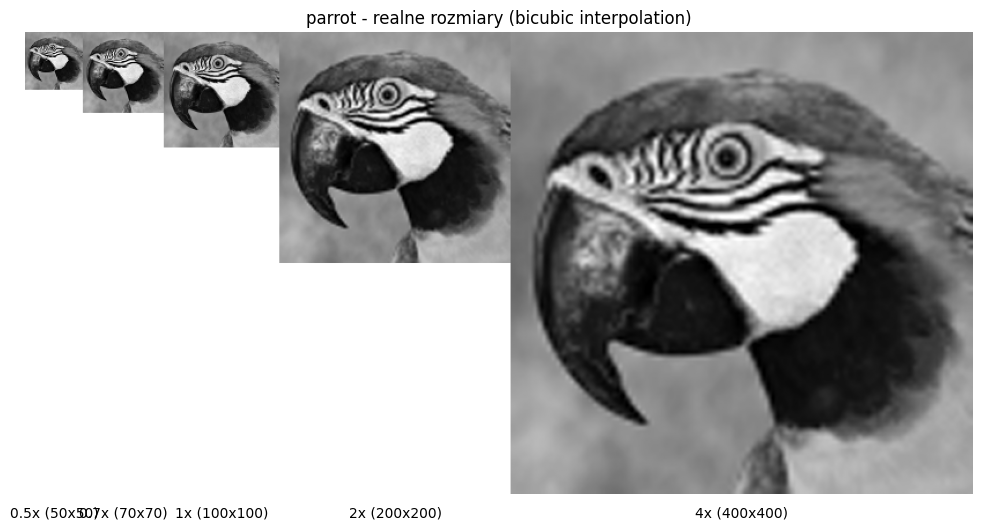

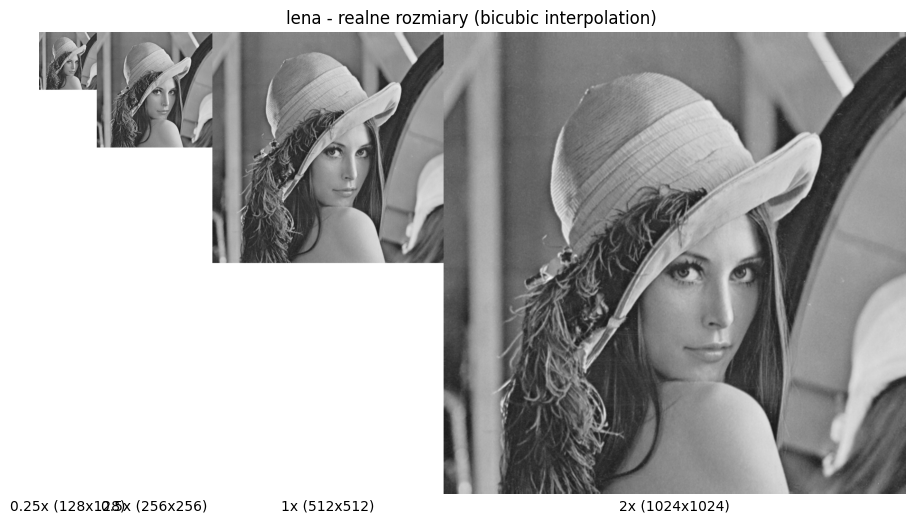

In [2]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/'
names = ["parrot", "clock", "chessboard", "bart", "firetruck"]
fileNames = ["parrot.bmp", "clock.bmp", "chessboard.bmp", "bart.png", "firetruck.jpg"]

images = {}

for name, fileName in zip(names, fileNames):
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, 'wb').write(r.content)
    img = cv2.imread(fileName)
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        images[name] = gray

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/03_Histogram/lenaRGB.bmp"
filename = "lenaRGB.bmp"
if not os.path.exists(filename):
    r = requests.get(url, allow_redirects=True)
    open(filename, 'wb').write(r.content)

lena = cv2.imread(filename)
lena = cv2.cvtColor(lena, cv2.COLOR_BGR2GRAY)
images["lena"] = lena


def bicubic_interpolation(image, scale):
    h, w = image.shape
    new_h, new_w = int(h * scale), int(w * scale)
    return cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

def compare_cases_scaled(function, cases):
    for name, scales in cases.items():
        image = images[name]

        results = []
        titles = []
        for s in scales:
            output = function(image, s)
            results.append(output)
            titles.append(f"{s}x ({output.shape[1]}x{output.shape[0]})")

        total_width = sum(r.shape[1] for r in results)
        max_height = max(r.shape[0] for r in results)
        canvas = np.ones((max_height, total_width), dtype=np.uint8) * 255

        current_x = 0
        for res in results:
            h, w = res.shape
            canvas[:h, current_x:current_x + w] = res
            current_x += w

        plt.figure(figsize=(14, 6))
        plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
        plt.title(f"{name} - realne rozmiary (bicubic interpolation)")
        plt.axis('off')

        current_x = 0
        for title, res in zip(titles, results):
            w = res.shape[1]
            plt.text(current_x + w / 2, max_height + 10, title,
                     color='black', ha='center', va='top', fontsize=10)
            current_x += w

        plt.show()


cases = {
    "parrot": (0.5, 0.7, 1, 2, 4),
    "lena": (0.25, 0.5, 1, 2)
}


compare_cases_scaled(bicubic_interpolation_manual, cases)
compare_cases_scaled(bicubic_interpolation, cases)